# Importation des bibliothèques

In [ ]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!pip install geopandas mplcursors -q
import geopandas as gpd
import mplcursors

# Chargement des données

In [ ]:
df = pd.read_excel('/content/US Superstore data.xls')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
print("Valeurs manquantes par colonne\n")
print(df.isnull().sum())
print(f"\nNombre de lignes dupliquées : {df.duplicated().sum()}")
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
print("\nLe Resumé des données après le preprocessing:")
df.info()

Valeurs manquantes par colonne

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Nombre de lignes dupliquées : 0

Le Resumé des données après le preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Custome

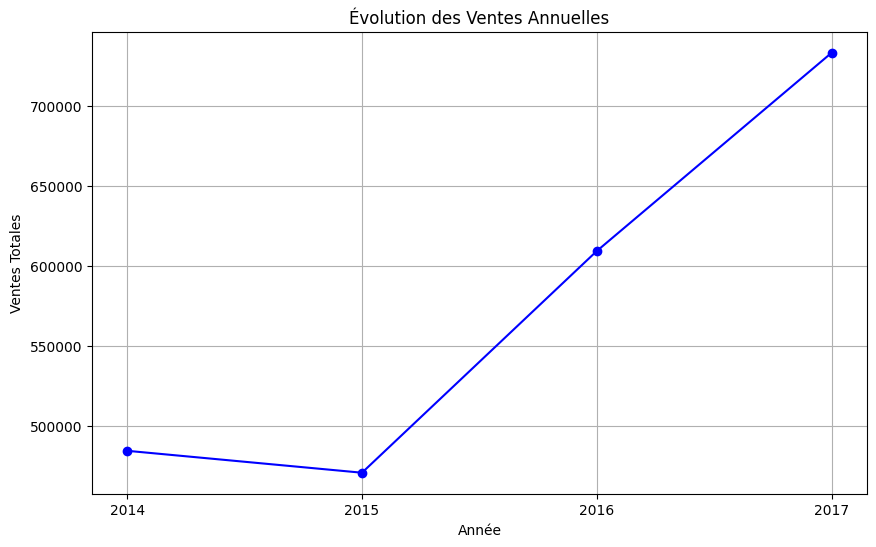

In [ ]:
# Grouper les ventes par année
df_yearly_sales = df.set_index('Order Date').resample('Y')['Sales'].sum().reset_index()
df_yearly_sales['Year'] = df_yearly_sales['Order Date'].dt.year

# Création du graphique avec Matplotlib
plt.figure(figsize=(10, 6))
plt.plot(df_yearly_sales['Year'], df_yearly_sales['Sales'], marker='o', linestyle='-', color='b')

plt.title('Évolution des Ventes Annuelles')
plt.xlabel('Année')
plt.ylabel('Ventes Totales')
plt.xticks(df_yearly_sales['Year'])
plt.grid(True)
plt.show()

Ce graphique représente les ventes totales réalisées chaque année.
Les ventes montrent une tendance globale à la hausse, ce qui indique que l'entreprise connaît une croissance.
l'année 2015 présente une baisse, cela peut être dû à :
une diminution de la demande,
des problèmes d'approvisionnement,
une concurrence plus forte,
ou une stratégie commerciale moins efficace.

In [ ]:
# Regrouper les ventes par Etat
sales_state = df.groupby("State")["Sales"].sum().reset_index()

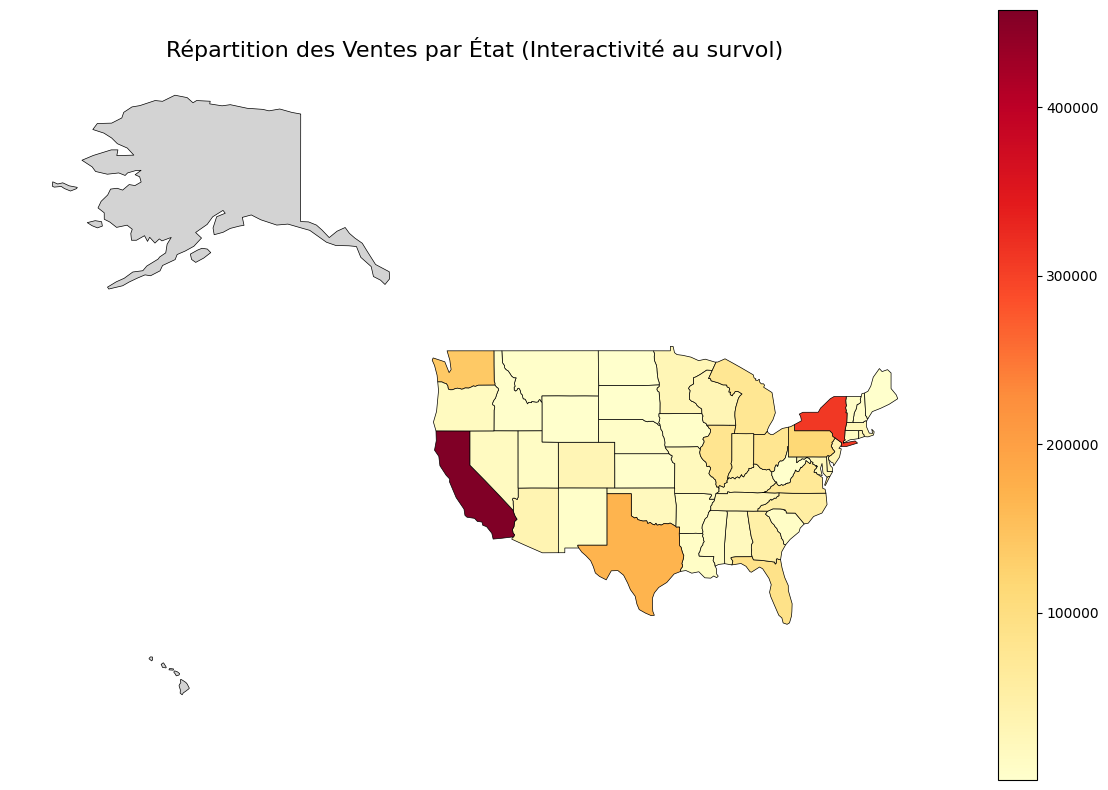

In [ ]:
# 1. Chargement des données géographiques des États US
usa_url = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_1_states_provinces.zip'
usa = gpd.read_file(usa_url)
# Filtrer pour les États-Unis
usa_gdf = usa[usa['iso_a2'] == 'US'].copy()

# 2. Fusion avec sales_state
merged = usa_gdf.merge(sales_state, left_on='name', right_on='State', how='left')

# 3. Création de la carte
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
merged.plot(column='Sales',
            ax=ax,
            legend=True,
            cmap='YlOrRd',
            missing_kwds={'color': 'lightgrey'},
            edgecolor='black',
            linewidth=0.5)

ax.set_title('Répartition des Ventes par État (Interactivité au survol)', fontsize=16)
ax.axis('off')

# 4. Ajout de l'interactivité (sans fonction personnalisée complexe)
cursor = mplcursors.cursor(ax, hover=True)
cursor.connect("add", lambda sel: sel.annotation.set_text(
    f"{merged.iloc[sel.index]['name']}\nVentes: ${merged.iloc[sel.index]['Sales']:,.2f}"
))
plt.show()

Cette carte met en évidence les États générant le plus de ventes.
Les couleurs foncées représentent les États ayant les ventes les plus élevées.
Le graphique permet immédiatement d'identifier :

les marchés principaux,
les marchés secondaires,
les zones peu exploitées.

On observe généralement que quelques États concentrent une grande partie des ventes (principe de Pareto).

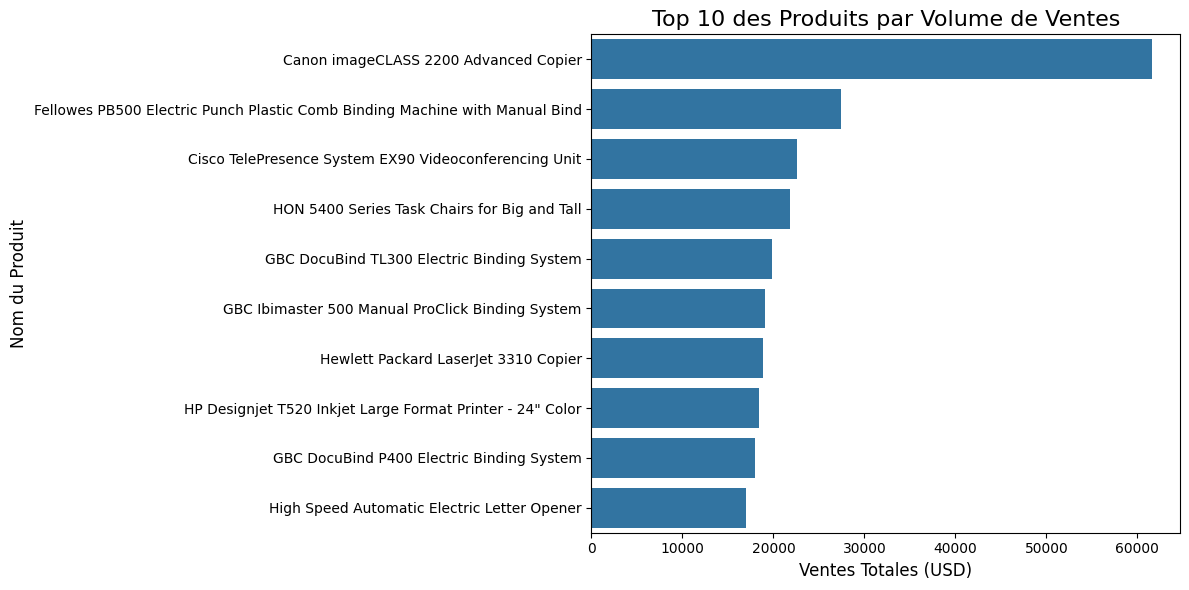

In [ ]:
# 1. Calcul des 10 produits les plus vendus
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

# 2. Création du graphique avec Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(data=top_products, x='Sales', y='Product Name')

plt.title('Top 10 des Produits par Volume de Ventes', fontsize=16)
plt.xlabel('Ventes Totales (USD)', fontsize=12)
plt.ylabel('Nom du Produit', fontsize=12)

plt.tight_layout()
plt.show()

Le graphique met en évidence les dix produits qui génèrent le plus de chiffre d'affaires.

Les principaux constats sont :

Le Canon imageCLASS 2200 Advanced Copier est le produit le plus vendu avec environ 61 000 USD de ventes.
Il surpasse largement les autres produits, avec plus de deux fois les ventes du deuxième produit.
Les neuf autres produits réalisent des ventes relativement proches, comprises entre 17 000 USD et 28 000 USD.

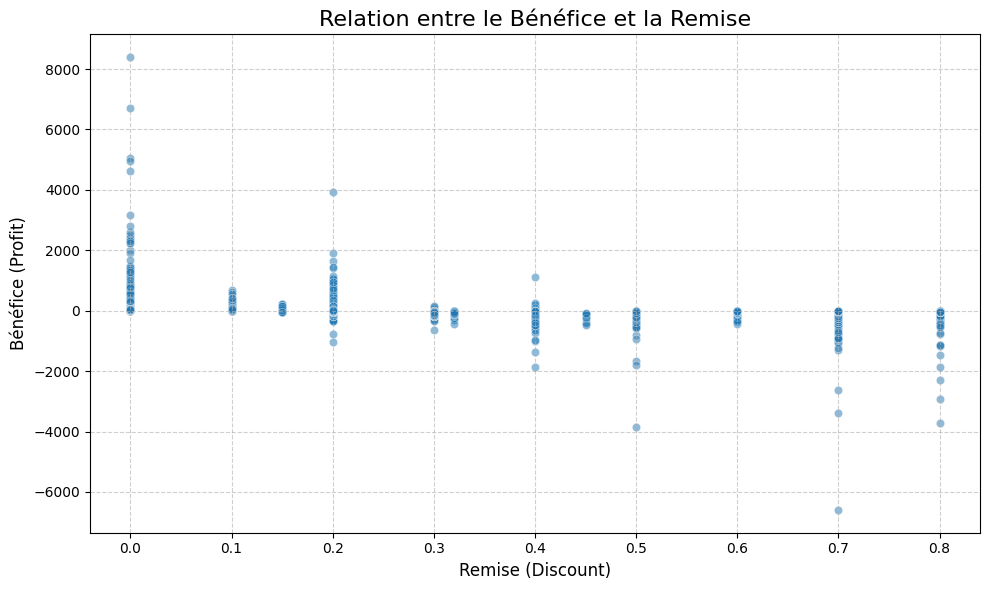

In [ ]:
# Création d'un nuage de points avec Seaborn pour analyser Profit vs Discount
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5)

plt.title('Relation entre le Bénéfice et la Remise', fontsize=16)
plt.xlabel('Remise (Discount)', fontsize=12)
plt.ylabel('Bénéfice (Profit)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Lorsque la remise est faible (0 %)
Les bénéfices sont généralement positifs.
Plusieurs ventes génèrent des profits très élevés (jusqu'à plus de 8 000 USD).
Lorsque la remise augmente

À partir de 20 % à 40 % de remise :

les bénéfices deviennent beaucoup plus dispersés ;
plusieurs ventes deviennent déficitaires.
Aux remises très élevées (50 %, 70 % et 80 %)

On observe de nombreuses transactions avec :

des bénéfices négatifs,
certaines pertes dépassant -6 000 USD.

Les remises importantes semblent donc fortement associées à des pertes financières.